# Импорт

In [ ]:
!pip install pymorphy3
!pip install gensim

In [ ]:
import re
import pandas as pd
import numpy as np
from typing import List, Tuple, Dict, Any, Optional
import matplotlib.pyplot as plt

import pymorphy3
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

from gensim.models import Word2Vec
from tqdm.notebook import tqdm

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Загрузка и подготовка

In [ ]:
df = pd.read_csv('parsed_reviews3.csv')
df = df.sample(n=5000, random_state=42)

df_sent = df.dropna(subset=['rating', 'title']).copy()
df_sent['label'] = (df_sent['rating'] > 3).astype(int)

df_clust = df_sent.drop_duplicates(subset=['title']).copy()

print(f"Всего отзывов для тональности: {len(df_sent)}")
print(f"Уникальных заголовков для кластеризации: {len(df_clust)}")

Всего отзывов для тональности: 5000
Уникальных заголовков для кластеризации: 3765


In [ ]:
df_sent

,body,title,rating,bank_name,date,label
37016,Самый лучший и удобный банк. Пользуюсь почти г...,Самый лучший и удобный банк.,5,Тинькофф Банк,2022-11-20 21:34:36,1
34410,&lt;p&gt;Тинькофф платинум - просто одна из лу...,Одна из самых удобных кредитных карт - точно Т...,5,Тинькофф Банк,2022-11-23 23:32:03,1
39247,&lt;p&gt;За пол года пользования дебетовой кар...,Пол года с Тинькофф,5,Тинькофф Банк,2022-11-17 13:54:15,1
23234,&lt;p&gt;Хочу благодарить сотрудников банка за...,Благодарность банку,5,Тинькофф Банк,2022-12-07 23:06:17,1
59699,&lt;p&gt;Пользуюсь услугами данного банка неск...,Кэшбэк и не только,5,Тинькофф Банк,2022-10-30 06:59:51,1
...,...,...,...,...,...,...
86467,"Брала кредит впервые, все очень понравилось,от...",Отличный банк!,5,Совкомбанк,2022-09-22 21:27:11,1
59869,"Оформил себе дебетовую карту Тинькофф Блэк, в ...",Лучшая дебетовая карта,5,Тинькофф Банк,2022-10-29 23:39:15,1
74988,&lt;p&gt;Выражаю свою благодарность отделению ...,Благодарность за полное сопровождение перевода...,5,Кредит Европа Банк,2022-10-25 17:06:12,1
63052,&lt;p&gt;Была кредитная карта с истёкшим беспр...,Небольшие проценты по кредитной карте,5,Тинькофф Банк,2022-10-28 15:24:25,1


# Предобработка

In [ ]:
def basic_clean(text):
    text = text.lower()
    return re.findall(r"[а-яё]+", text)

def lemmatize_words(words, morph):
    return [morph.parse(w)[0].normal_form for w in words]

def remove_stopwords(words, stop_set):
    return [w for w in words if w not in stop_set]

def preprocess_text(text, lemmatize = True, remove_stop = True):
    words = basic_clean(text)
    if lemmatize:
        morph = pymorphy3.MorphAnalyzer()
        words = lemmatize_words(words, morph)
    if remove_stop:
        stop_set = set(stopwords.words('russian'))
        words = remove_stopwords(words, stop_set)
    return ' '.join(words)


# Тональность

In [ ]:
class SentimentClassifier:
    def __init__(self,
                 preprocess = False,
                 max_features = 5000,
                 alpha = 0.01,
                 random_state = 42):
        self.preprocess = preprocess
        self.max_features = max_features
        self.alpha = alpha
        self.random_state = random_state

        self.vectorizer = None
        self.scaler = None
        self.model = None

    def _prepare_texts(self, texts):
        if self.preprocess:
            return [preprocess_text(t, lemmatize=True, remove_stop=True)
                    for t in tqdm(texts, desc='Preprocessing (sent)')]
        else:
            return [' '.join(basic_clean(t)) for t in texts]

    def fit(self, X_train, y_train):
        self.X_train_clean = self._prepare_texts(X_train)

        self.vectorizer = CountVectorizer(
            analyzer='word',
            max_features=self.max_features,
            token_pattern=r'[а-яё]+',
            lowercase=True
        )
        X_train_vec = self.vectorizer.fit_transform(self.X_train_clean)

        self.scaler = StandardScaler(with_mean=False)
        X_train_scaled = self.scaler.fit_transform(X_train_vec)

        self.model = SGDClassifier(
            loss='log_loss',
            penalty='l2',
            alpha=self.alpha,
            random_state=self.random_state
        )
        self.model.fit(X_train_scaled, y_train)

    def predict(self, X):
        X_clean = self._prepare_texts(X)
        X_vec = self.vectorizer.transform(X_clean)
        X_scaled = self.scaler.transform(X_vec)
        return self.model.predict(X_scaled)

    def evaluate(self, X, y):
        preds = self.predict(X)
        acc = accuracy_score(y, preds)
        f1 = f1_score(y, preds, average="macro")
        return acc, f1

    def get_top_features(self, n = 20):
        coef = self.model.coef_[0]
        feature_names = self.vectorizer.get_feature_names_out()
        word_coef = list(zip(feature_names, coef))
        sorted_word_coef = sorted(word_coef, key=lambda x: x[1])

        print(f"Топ {n} отрицательных слов (с препроцессингом: {self.preprocess})")
        for word, c in sorted_word_coef[:n]:
            print(f"{word}: {c:.4f}")

        print(f"\nТоп {n} положительных слов (с препроцессингом: {self.preprocess})")
        for word, c in sorted_word_coef[-n:][::-1]:
            print(f"{word}: {c:.4f}")

In [ ]:
X_titles = df_sent['title'].tolist()
y_labels = df_sent['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_titles, y_labels,
    test_size=0.2,
    stratify=y_labels,
    random_state=42
)

Без препроцессинга

In [ ]:
clf_no_prep = SentimentClassifier(preprocess=False, max_features=3000)
clf_no_prep.fit(X_train, y_train)
acc_no, f1_no = clf_no_prep.evaluate(X_test, y_test)
print(f"Без препроцессинга -> Accuracy: {acc_no:.4f}, F1: {f1_no:.4f}")
clf_no_prep.get_top_features(n=10)

Без препроцессинга -> Accuracy: 0.8990, F1: 0.8516
Топ 10 отрицательных слов (с препроцессингом: False)
не: -0.4324
обман: -0.3405
отвратительный: -0.3111
г: -0.2310
ужасный: -0.2220
нет: -0.2191
отвратительное: -0.2187
ужасное: -0.2121
жалоба: -0.2049
год: -0.1958

Топ 10 положительных слов (с препроцессингом: False)
благодарность: 0.6164
тинькофф: 0.4974
отзыв: 0.4920
банк: 0.4620
лучший: 0.4617
отличный: 0.3942
обслуживание: 0.3299
поддержка: 0.3258
хороший: 0.2886
дебетовая: 0.2874


С препроцессингом

In [ ]:
clf_prep = SentimentClassifier(preprocess=True, max_features=3000)
clf_prep.fit(X_train, y_train)
acc_prep, f1_prep = clf_prep.evaluate(X_test, y_test)
print(f"С препроцессингом -> Accuracy: {acc_prep:.4f}, F1: {f1_prep:.4f}")
clf_prep.get_top_features(n=10)

Preprocessing (sent):   0%|          | 0/4000 [00:00<?, ?it/s]

Preprocessing (sent):   0%|          | 0/1000 [00:00<?, ?it/s]

С препроцессингом -> Accuracy: 0.9000, F1: 0.8524
Топ 10 отрицательных слов (с препроцессингом: True)
отвратительный: -0.4225
обман: -0.4102
ужасный: -0.3475
отказ: -0.2608
заблокировать: -0.2512
деньга: -0.2338
жалоба: -0.2201
обманывать: -0.2177
г: -0.2013
первый: -0.1995

Топ 10 положительных слов (с препроцессингом: True)
хороший: 0.6709
благодарность: 0.6377
тинькофф: 0.5586
отличный: 0.5150
отзыв: 0.5099
банк: 0.4951
карта: 0.3959
поддержка: 0.3402
обслуживание: 0.3099
спасибо: 0.2914


# Кластеризация

In [ ]:
class TextClusterer:
    def __init__(self,
                 preprocess = False,
                 w2v_size = 100,
                 w2v_window = 5,
                 w2v_min_count = 5,
                 n_clusters = 5,
                 random_state = 42):
        self.preprocess = preprocess
        self.w2v_size = w2v_size
        self.w2v_window = w2v_window
        self.w2v_min_count = w2v_min_count
        self.n_clusters = n_clusters
        self.random_state = random_state

        self.w2v_model = None
        self.kmeans = None
        self.vectors_ = None
        self.labels_ = None
        self.words_lists_ = None

    def _prepare_texts(self, texts):
        if self.preprocess:
            processed = []
            for t in tqdm(texts, desc='Preprocessing (clust)'):
                words = basic_clean(t)
                morph = pymorphy3.MorphAnalyzer()
                lemm = lemmatize_words(words, morph)
                stop_set = set(stopwords.words('russian'))
                no_stop = remove_stopwords(lemm, stop_set)
                processed.append(no_stop)
            return processed
        else:
            return [basic_clean(t) for t in texts]

    def fit(self, texts):
        self.kmeans = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state
        )
        self.labels_ = self.kmeans.fit_predict(self.vectors_)

    def _text_to_vector(self, words):
        vecs = []
        for w in words:
            if self.w2v_model.wv.has_index_for(w):
                vecs.append(self.w2v_model.wv.get_vector(w))
        if len(vecs) == 0:
            return self.w2v_model.wv.vectors.mean(axis=0)
        return np.mean(vecs, axis=0)

    def _compute_vectors(self, texts):
        self.words_lists_ = self._prepare_texts(texts)

        self.w2v_model = Word2Vec(
            vector_size=self.w2v_size,
            window=self.w2v_window,
            min_count=self.w2v_min_count,
            negative=10,
            seed=self.random_state,
            workers=4
        )
        self.w2v_model.build_vocab(self.words_lists_)
        self.w2v_model.train(
            self.words_lists_,
            total_examples=self.w2v_model.corpus_count,
            epochs=10
        )
        self.vectors_ = np.array([
            self._text_to_vector(words) for words in tqdm(self.words_lists_, desc='Vectorizing')
        ])

    def find_optimal_k(self, texts, k_range = range(2, 11), max_points = 5000):
        if len(texts) > max_points:
            idx = np.random.choice(len(texts), max_points, replace=False)
            texts_sub = [texts[i] for i in idx]
        else:
            texts_sub = texts

        self._compute_vectors(texts)

        best_k, best_score = -1, -1
        for k in tqdm(k_range, desc='Silhouette selection'):
            kmeans = KMeans(n_clusters=k, random_state=self.random_state, n_init=10)
            labels = kmeans.fit_predict(self.vectors_)
            score = silhouette_score(self.vectors_, labels, metric='cosine')
            if score > best_score:
                best_score = score
                best_k = k

        print(f"Оптимальное k по силуэту: {best_k} (score = {best_score:.3f})")
        return best_k

    def visualize(self, texts = None, max_points = 3000):

        n_show = min(len(self.vectors_), max_points)
        idx = np.random.choice(len(self.vectors_), n_show, replace=False)

        tsne = TSNE(
            n_components=2,
            perplexity=30,
            random_state=self.random_state,
            metric='cosine'
        )
        coords = tsne.fit_transform(self.vectors_[idx])

        plt.figure(figsize=(10, 7))
        scatter = plt.scatter(
            coords[:, 0], coords[:, 1],
            c=self.labels_[idx],
            alpha=0.6
        )
        plt.colorbar(scatter, label='Кластер')
        plt.title(f"t-SNE визуализация кластеров (препроцессинг: {self.preprocess})")
        plt.xlabel('Компонента 1')
        plt.ylabel('Компонента 2')
        plt.grid(alpha=0.3)
        plt.show()


    def show_cluster_examples(self, texts, n_examples = 2):
        unique_labels = np.unique(self.labels_)
        print(f"Примеры заголовков по кластерам (препроцессинг: {self.preprocess})")
        for label in unique_labels:
            indices = np.where(self.labels_ == label)[0]
            print(f"\nКластер {label} (всего {len(indices)} текстов):")
            for i in indices[:n_examples]:
                print(f"  - {texts[i]}")

In [ ]:
unique_titles = df_clust['title'].tolist()

Без препроцессинга

Vectorizing:   0%|          | 0/3765 [00:00<?, ?it/s]

Silhouette selection:   0%|          | 0/9 [00:00<?, ?it/s]

Оптимальное k по силуэту: 2 (score = 0.078)


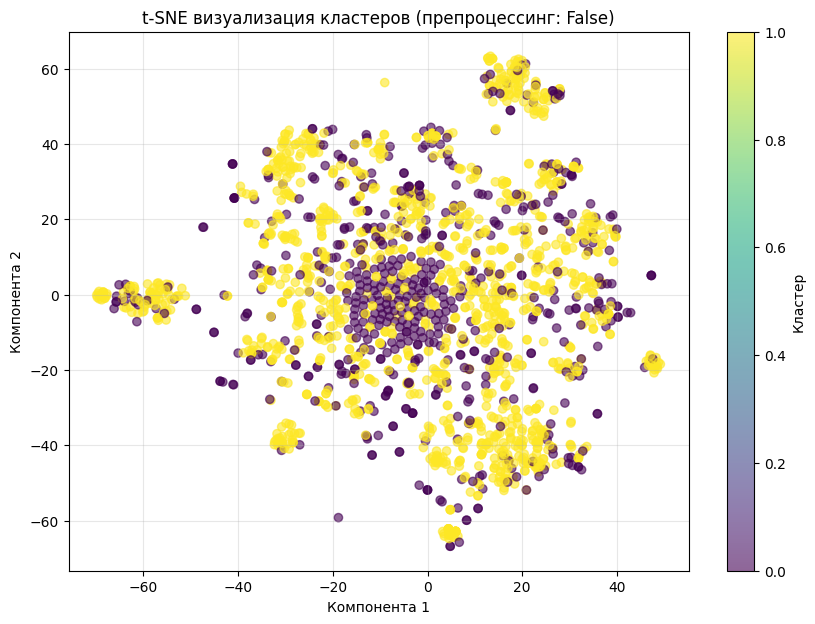

Примеры заголовков по кластерам (препроцессинг: False)

Кластер 0 (всего 995 текстов):
  - Использование дебетовой карты
  - Оплата в любых магазинах

Кластер 1 (всего 2770 текстов):
  - Самый лучший и удобный банк.
  - Одна из самых удобных кредитных карт - точно Тинькофф!


In [ ]:
clusterer_no = TextClusterer(preprocess=False, w2v_size=50, random_state=42)
optimal_k = clusterer_no.find_optimal_k(unique_titles, k_range=range(2, 11), max_points=3000)
clusterer_no.n_clusters = optimal_k
clusterer_no.fit(unique_titles)
clusterer_no.visualize(texts=unique_titles, max_points=2000)
clusterer_no.show_cluster_examples(texts=unique_titles, n_examples=2)

С препроцессингом

Preprocessing (clust):   0%|          | 0/3765 [00:00<?, ?it/s]

Vectorizing:   0%|          | 0/3765 [00:00<?, ?it/s]

Silhouette selection:   0%|          | 0/9 [00:00<?, ?it/s]

Оптимальное k по силуэту: 2 (score = 0.133)


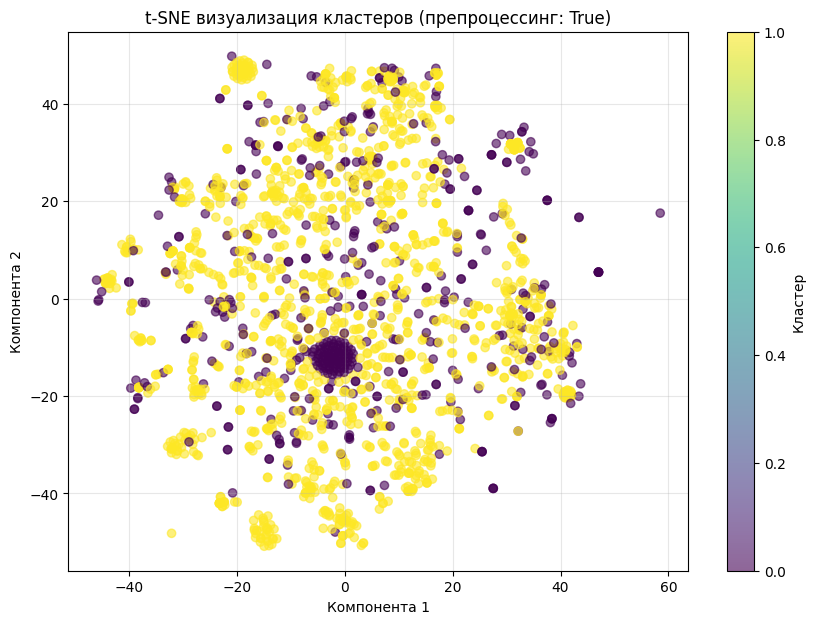

Примеры заголовков по кластерам (препроцессинг: True)

Кластер 0 (всего 894 текстов):
  - Модульбанк
  - Односторонний порядок

Кластер 1 (всего 2871 текстов):
  - Самый лучший и удобный банк.
  - Одна из самых удобных кредитных карт - точно Тинькофф!


In [ ]:
clusterer_yes = TextClusterer(preprocess=True, w2v_size=50, random_state=42)
optimal_k = clusterer_yes.find_optimal_k(unique_titles, k_range=range(2, 11), max_points=3000)
clusterer_yes.n_clusters = optimal_k
clusterer_yes.fit(unique_titles)
clusterer_yes.visualize(texts=unique_titles, max_points=2000)
clusterer_yes.show_cluster_examples(texts=unique_titles, n_examples=2)

Preprocessing (clust):   0%|          | 0/3765 [00:00<?, ?it/s]

Vectorizing:   0%|          | 0/3765 [00:00<?, ?it/s]

Silhouette selection:   0%|          | 0/9 [00:00<?, ?it/s]

Оптимальное k по силуэту: 2 (score = 0.134)


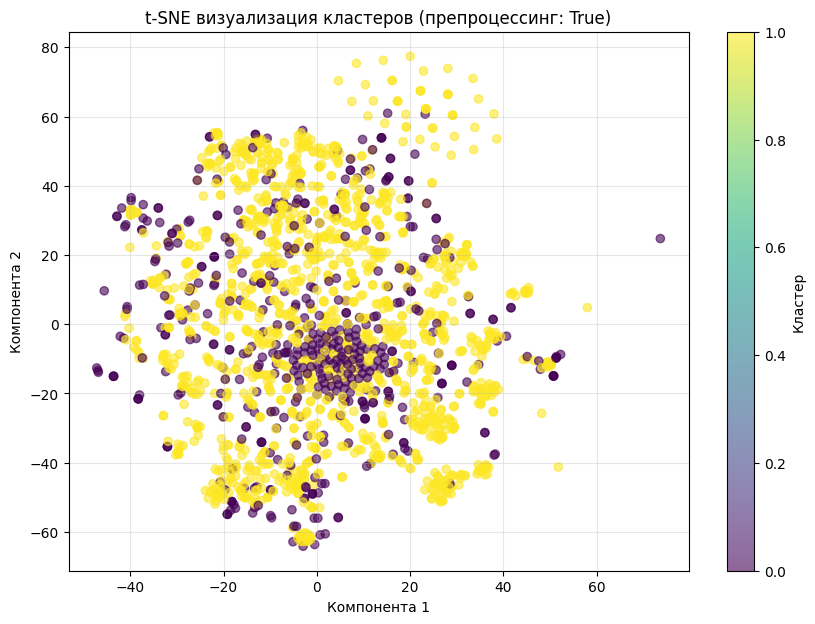

Примеры заголовков по кластерам (препроцессинг: True)

Кластер 0 (всего 893 текстов):
  - Модульбанк
  - Односторонний порядок

Кластер 1 (всего 2872 текстов):
  - Самый лучший и удобный банк.
  - Одна из самых удобных кредитных карт - точно Тинькофф!


In [ ]:
clusterer_yes = TextClusterer(preprocess=True, w2v_size=50, random_state=42)
optimal_k = clusterer_yes.find_optimal_k(unique_titles, k_range=range(2, 11), max_points=3000)
clusterer_yes.n_clusters = optimal_k
clusterer_yes.fit(unique_titles)
clusterer_yes.visualize(texts=unique_titles, max_points=2000)
clusterer_yes.show_cluster_examples(texts=unique_titles, n_examples=2)

In [ ]:
clusterer_yes.show_cluster_examples(texts=unique_titles, n_examples=10)

Примеры заголовков по кластерам (препроцессинг: True)

Кластер 0 (всего 893 текстов):
  - Модульбанк
  - Односторонний порядок
  - Банк постоянно обманывает
  - Не выполняют обязательства
  - Нормальная карта
  - Выражаю благодарность
  - Преимущества карты Tinkoff black
  - Телефонное хамство от Почта Банка
  - Достояние Росссии
  - Банк не рекомендую

Кластер 1 (всего 2872 текстов):
  - Самый лучший и удобный банк.
  - Одна из самых удобных кредитных карт - точно Тинькофф!
  - Пол года с Тинькофф
  - Благодарность банку
  - Кэшбэк и не только
  - Дебетовая карта Тинькофф банка
  - Хороший банк
  - Обманывают на стадии оформления карты
  - Кредит
  - Использование дебетовой карты


In [ ]:
clusterer_no.show_cluster_examples(texts=unique_titles, n_examples=10)

Примеры заголовков по кластерам (препроцессинг: False)

Кластер 0 (всего 995 текстов):
  - Использование дебетовой карты
  - Оплата в любых магазинах
  - Модульбанк
  - Односторонний порядок
  - Самый лучший специалист
  - Банк постоянно обманывает
  - Услуга
  - Хорошее обслуживание
  - Крутой банк
  - Выражаю благодарность

Кластер 1 (всего 2770 текстов):
  - Самый лучший и удобный банк.
  - Одна из самых удобных кредитных карт - точно Тинькофф!
  - Пол года с Тинькофф
  - Благодарность банку
  - Кэшбэк и не только
  - Дебетовая карта Тинькофф банка
  - Хороший банк
  - Обманывают на стадии оформления карты
  - Кредит
  - Трата времени и нервов
